In [3]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.feature_selection import SequentialFeatureSelector
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [4]:
df = pd.read_csv("athlete_events.csv")


print(df.info())
print(df.isnull().sum())
df.drop_duplicates(inplace=True)
df


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 271116 entries, 0 to 271115
Data columns (total 15 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   ID      271116 non-null  int64  
 1   Name    271116 non-null  object 
 2   Sex     271116 non-null  object 
 3   Age     261642 non-null  float64
 4   Height  210945 non-null  float64
 5   Weight  208241 non-null  float64
 6   Team    271116 non-null  object 
 7   NOC     271116 non-null  object 
 8   Games   271116 non-null  object 
 9   Year    271116 non-null  int64  
 10  Season  271116 non-null  object 
 11  City    271116 non-null  object 
 12  Sport   271116 non-null  object 
 13  Event   271116 non-null  object 
 14  Medal   39783 non-null   object 
dtypes: float64(3), int64(2), object(10)
memory usage: 31.0+ MB
None
ID             0
Name           0
Sex            0
Age         9474
Height     60171
Weight     62875
Team           0
NOC            0
Games          0
Year           0
Seas

,ID,Name,Sex,Age,Height,Weight,Team,NOC,Games,Year,Season,City,Sport,Event,Medal
0,1,A Dijiang,M,24.0,180.0,80.0,China,CHN,1992 Summer,1992,Summer,Barcelona,Basketball,Basketball Men's Basketball,NaN
1,2,A Lamusi,M,23.0,170.0,60.0,China,CHN,2012 Summer,2012,Summer,London,Judo,Judo Men's Extra-Lightweight,NaN
2,3,Gunnar Nielsen Aaby,M,24.0,NaN,NaN,Denmark,DEN,1920 Summer,1920,Summer,Antwerpen,Football,Football Men's Football,NaN
3,4,Edgar Lindenau Aabye,M,34.0,NaN,NaN,Denmark/Sweden,DEN,1900 Summer,1900,Summer,Paris,Tug-Of-War,Tug-Of-War Men's Tug-Of-War,Gold
4,5,Christine Jacoba Aaftink,F,21.0,185.0,82.0,Netherlands,NED,1988 Winter,1988,Winter,Calgary,Speed Skating,Speed Skating Women's 500 metres,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
271111,135569,Andrzej ya,M,29.0,179.0,89.0,Poland-1,POL,1976 Winter,1976,Winter,Innsbruck,Luge,Luge Mixed (Men)'s Doubles,NaN
271112,135570,Piotr ya,M,27.0,176.0,59.0,Poland,POL,2014 Winter,2014,Winter,Sochi,Ski Jumping,"Ski Jumping Men's Large Hill, Individual",NaN
271113,135570,Piotr ya,M,27.0,176.0,59.0,Poland,POL,2014 Winter,2014,Winter,Sochi,Ski Jumping,"Ski Jumping Men's Large Hill, Team",NaN
271114,135571,Tomasz Ireneusz ya,M,30.0,185.0,96.0,Poland,POL,1998 Winter,1998,Winter,Nagano,Bobsleigh,Bobsleigh Men's Four,NaN


In [5]:
athlete_count = df.groupby(['Year', 'NOC'])['ID'].nunique().reset_index()
athlete_count.rename(columns={'ID': 'Athlete_Count'}, inplace=True)
df = df.merge(athlete_count, on=['Year', 'NOC'], how='left')

event_count = df.groupby(['Year', 'NOC'])['Event'].nunique().reset_index()
event_count.rename(columns={'Event': 'Event_Count'}, inplace=True)
df = df.merge(event_count, on=['Year', 'NOC'], how='left')
df

,ID,Name,Sex,Age,Height,Weight,Team,NOC,Games,Year,Season,City,Sport,Event,Medal,Athlete_Count,Event_Count
0,1,A Dijiang,M,24.0,180.0,80.0,China,CHN,1992 Summer,1992,Summer,Barcelona,Basketball,Basketball Men's Basketball,NaN,276,176
1,2,A Lamusi,M,23.0,170.0,60.0,China,CHN,2012 Summer,2012,Summer,London,Judo,Judo Men's Extra-Lightweight,NaN,375,206
2,3,Gunnar Nielsen Aaby,M,24.0,NaN,NaN,Denmark,DEN,1920 Summer,1920,Summer,Antwerpen,Football,Football Men's Football,NaN,154,66
3,4,Edgar Lindenau Aabye,M,34.0,NaN,NaN,Denmark/Sweden,DEN,1900 Summer,1900,Summer,Paris,Tug-Of-War,Tug-Of-War Men's Tug-Of-War,Gold,13,14
4,5,Christine Jacoba Aaftink,F,21.0,185.0,82.0,Netherlands,NED,1988 Winter,1988,Winter,Calgary,Speed Skating,Speed Skating Women's 500 metres,NaN,158,96
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
269726,135569,Andrzej ya,M,29.0,179.0,89.0,Poland-1,POL,1976 Winter,1976,Winter,Innsbruck,Luge,Luge Mixed (Men)'s Doubles,NaN,263,141
269727,135570,Piotr ya,M,27.0,176.0,59.0,Poland,POL,2014 Winter,2014,Winter,Sochi,Ski Jumping,"Ski Jumping Men's Large Hill, Individual",NaN,58,58
269728,135570,Piotr ya,M,27.0,176.0,59.0,Poland,POL,2014 Winter,2014,Winter,Sochi,Ski Jumping,"Ski Jumping Men's Large Hill, Team",NaN,58,58
269729,135571,Tomasz Ireneusz ya,M,30.0,185.0,96.0,Poland,POL,1998 Winter,1998,Winter,Nagano,Bobsleigh,Bobsleigh Men's Four,NaN,39,35


In [6]:
df['Medal_Value'] = df['Medal'].map({
    'Gold': 3,
    'Silver': 2,
    'Bronze': 1
})
df['total_medals'] = df['Medal_Value'].fillna(0)
medal_count = df[df['Medal'].notna()] \
    .groupby(['Year', 'NOC'])['Medal'] \
    .count() \
    .reset_index()

df.drop(columns=[ 'Name', 'Games'], inplace=True)

In [7]:
df = df.sort_values(by=['Year', 'NOC']).reset_index(drop=True)

df

,ID,Sex,Age,Height,Weight,Team,NOC,Year,Season,City,Sport,Event,Medal,Athlete_Count,Event_Count,Medal_Value,total_medals
0,35698,M,22.0,NaN,NaN,Australia,AUS,1896,Summer,Athina,Tennis,Tennis Men's Singles,NaN,1,5,NaN,0.0
1,35698,M,22.0,NaN,NaN,Australia/Great Britain,AUS,1896,Summer,Athina,Tennis,Tennis Men's Doubles,Bronze,1,5,1.0,1.0
2,35698,M,22.0,NaN,NaN,Australia,AUS,1896,Summer,Athina,Athletics,Athletics Men's 800 metres,Gold,1,5,3.0,3.0
3,35698,M,22.0,NaN,NaN,Australia,AUS,1896,Summer,Athina,Athletics,"Athletics Men's 1,500 metres",Gold,1,5,3.0,3.0
4,35698,M,22.0,NaN,NaN,Australia,AUS,1896,Summer,Athina,Athletics,Athletics Men's Marathon,NaN,1,5,NaN,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
269726,87478,F,29.0,158.0,57.0,Zimbabwe,ZIM,2016,Summer,Rio de Janeiro,Football,Football Women's Football,NaN,30,13,NaN,0.0
269727,92718,M,27.0,191.0,87.0,Zimbabwe,ZIM,2016,Summer,Rio de Janeiro,Rowing,Rowing Men's Single Sculls,NaN,30,13,NaN,0.0
269728,116713,M,37.0,186.0,78.0,Zimbabwe,ZIM,2016,Summer,Rio de Janeiro,Archery,Archery Men's Individual,NaN,30,13,NaN,0.0
269729,120082,F,29.0,175.0,72.0,Zimbabwe,ZIM,2016,Summer,Rio de Janeiro,Rowing,Rowing Women's Single Sculls,NaN,30,13,NaN,0.0


In [8]:
final_df = df.groupby(['Year', 'NOC']).agg({
    'ID': 'nunique',         
    'Event': 'nunique',       
    'Medal_Value': 'sum',     
    'Medal': lambda x: x.notna().sum()   
}).reset_index()
final_df.rename(columns={
    'ID': 'Athlete_Count',
    'Event': 'Event_Count',
    'Medal_Value': 'Medal_Points',
    'Medal': 'Total_Medals'
}, inplace=True)
final_df = final_df.sort_values(by=['Year', 'NOC']).reset_index(drop=True)
final_df['Prev_Medals'] = final_df.groupby('NOC')['Total_Medals'].shift(1)
final_df['Prev_Medals'] = final_df['Prev_Medals'].fillna(0)
final_df

,Year,NOC,Athlete_Count,Event_Count,Medal_Points,Total_Medals,Prev_Medals
0,1896,AUS,1,5,7.0,3,0.0
1,1896,AUT,3,8,10.0,5,0.0
2,1896,DEN,3,12,10.0,6,0.0
3,1896,FRA,12,18,25.0,11,0.0
4,1896,GBR,10,19,18.0,9,0.0
...,...,...,...,...,...,...,...
3300,2016,VIE,22,24,5.0,2,0.0
3301,2016,VIN,4,4,0.0,0,0.0
3302,2016,YEM,3,3,0.0,0,0.0
3303,2016,ZAM,7,7,0.0,0,0.0


In [9]:
final_df['Medal_Rolling_Avg'] = final_df.groupby('NOC')['Total_Medals'] \
    .rolling(3).mean().reset_index(0, drop=True)
final_df['Medal_Rolling_Avg'] = final_df['Medal_Rolling_Avg'].fillna(0)
final_df

,Year,NOC,Athlete_Count,Event_Count,Medal_Points,Total_Medals,Prev_Medals,Medal_Rolling_Avg
0,1896,AUS,1,5,7.0,3,0.0,0.0
1,1896,AUT,3,8,10.0,5,0.0,0.0
2,1896,DEN,3,12,10.0,6,0.0,0.0
3,1896,FRA,12,18,25.0,11,0.0,0.0
4,1896,GBR,10,19,18.0,9,0.0,0.0
...,...,...,...,...,...,...,...,...
3300,2016,VIE,22,24,5.0,2,0.0,1.0
3301,2016,VIN,4,4,0.0,0,0.0,0.0
3302,2016,YEM,3,3,0.0,0,0.0,0.0
3303,2016,ZAM,7,7,0.0,0,0.0,0.0


In [10]:
final_df[final_df['NOC'] == 'USA']

,Year,NOC,Athlete_Count,Event_Count,Medal_Points,Total_Medals,Prev_Medals,Medal_Rolling_Avg
11,1896,USA,14,16,49.0,20,0.0,0.000000
42,1900,USA,75,41,139.0,63,20.0,0.000000
57,1904,USA,524,95,791.0,394,63.0,159.000000
78,1906,USA,38,28,54.0,24,394.0,160.333333
100,1908,USA,122,52,149.0,65,24.0,161.000000
129,1912,USA,174,68,224.0,107,65.0,65.333333
157,1920,USA,288,113,461.0,194,107.0,122.000000
203,1924,USA,323,119,436.0,194,194.0,165.000000
248,1928,USA,304,108,238.0,102,194.0,163.333333
295,1932,USA,538,136,473.0,223,102.0,173.000000


In [11]:
df = pd.get_dummies(final_df, columns=['NOC'])
df

,Year,Athlete_Count,Event_Count,Medal_Points,Total_Medals,Prev_Medals,Medal_Rolling_Avg,NOC_AFG,NOC_AHO,NOC_ALB,...,NOC_VIE,NOC_VIN,NOC_VNM,NOC_WIF,NOC_YAR,NOC_YEM,NOC_YMD,NOC_YUG,NOC_ZAM,NOC_ZIM
0,1896,1,5,7.0,3,0.0,0.0,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,1896,3,8,10.0,5,0.0,0.0,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,1896,3,12,10.0,6,0.0,0.0,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,1896,12,18,25.0,11,0.0,0.0,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,1896,10,19,18.0,9,0.0,0.0,False,False,False,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3300,2016,22,24,5.0,2,0.0,1.0,False,False,False,...,True,False,False,False,False,False,False,False,False,False
3301,2016,4,4,0.0,0,0.0,0.0,False,False,False,...,False,True,False,False,False,False,False,False,False,False
3302,2016,3,3,0.0,0,0.0,0.0,False,False,False,...,False,False,False,False,False,True,False,False,False,False
3303,2016,7,7,0.0,0,0.0,0.0,False,False,False,...,False,False,False,False,False,False,False,False,True,False


/var/folders/nr/40b30qld2473f5h59rq9tnm80000gn/T/ipykernel_18783/4004013750.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Correlation', y='Feature', data=corr_df, palette='coolwarm',orient="h")


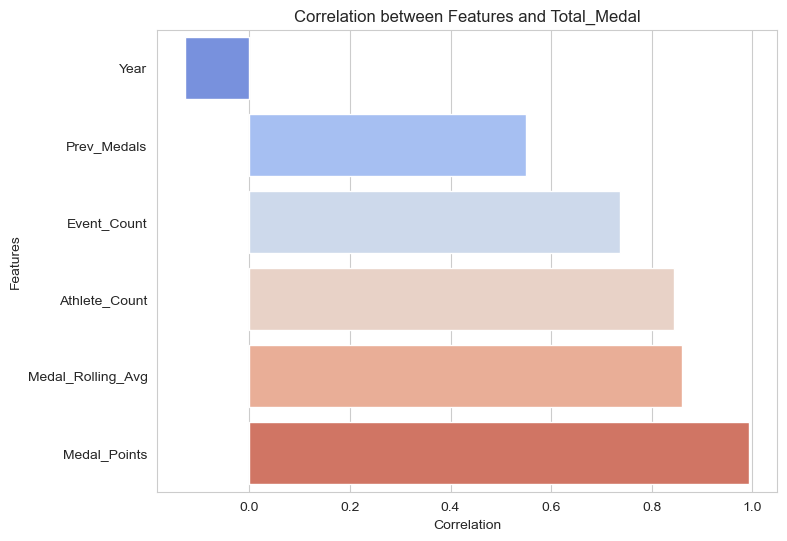

In [12]:
numeric_df = final_df.select_dtypes(include=['number'])
corr = numeric_df.corr()['Total_Medals'].drop('Total_Medals').sort_values()
corr_df = corr.reset_index()
corr_df.columns = ['Feature', 'Correlation']
sns.set_style("whitegrid")
plt.figure(figsize=(8,6))
sns.barplot(x='Correlation', y='Feature', data=corr_df, palette='coolwarm',orient="h")

plt.title("Correlation between Features and Total_Medal")
plt.xlabel("Correlation")
plt.ylabel("Features")

plt.show()

In [19]:
X = df.drop(columns=['Total_Medals', 'Medal_Points'])
y = df['Total_Medals']

print(X)
print("\n\n")
print(y)


      Year  Athlete_Count  Event_Count  Prev_Medals  Medal_Rolling_Avg  \
0     1896              1            5          0.0                0.0   
1     1896              3            8          0.0                0.0   
2     1896              3           12          0.0                0.0   
3     1896             12           18          0.0                0.0   
4     1896             10           19          0.0                0.0   
...    ...            ...          ...          ...                ...   
3300  2016             22           24          0.0                1.0   
3301  2016              4            4          0.0                0.0   
3302  2016              3            3          0.0                0.0   
3303  2016              7            7          0.0                0.0   
3304  2016             30           13          0.0                0.0   

      NOC_AFG  NOC_AHO  NOC_ALB  NOC_ALG  NOC_AND  ...  NOC_VIE  NOC_VIN  \
0       False    False    False    